# Análisis de texto de Python: Bag of Words

* * *

<div class = "alerta de alerta-exuces">

### Objetivos de aprendizaje

* Aprenda a convertir los datos de texto en números a través de un enfoque de la bolsa de palabras.
* Comprender el algoritmo TF-IDF y cómo complementa la representación de la bolsa de palabras.
* Implementar la bolsa de palabras y TF-IDF utilizando el paquete `sklearn` y comprenda su configuración de parámetros.
* Use las representaciones numéricas de los datos de texto para realizar análisis de sentimientos.
</div>

### iconos utilizados en este cuaderno
🔔 ** Pregunta **: Una pregunta rápida para ayudarlo a comprender lo que está pasando. <br>
🥊 ** Desafío **: Experiencia interactiva.¡Trabajaremos en el taller! <br>
🎬 ** Demo **: Mostrar algo más avanzado, ¡para que sepa para qué se puede usar Python! <br>

### Secciones
1. [Análisis de datos exploratorios] (#Sección 1)
2. [Preprocesamiento] (#Sección2)
3. [La representación de la bolsa de las palabras] (#Sección 3)
4. [Frecuencia de documento de la frecuencia de término] (#Sección 4)
5. [Clasificación de sentimientos utilizando la representación TF-IDF] (#Sección 5)

En la parte anterior, aprendimos a realizar el preprocesamiento de texto.Sin embargo, no nos movimos más allá de los datos de texto en sí.Si estamos interesados ​​en hacer algún análisis computacional en los datos de texto, aún necesitamos enfoques para convertir el texto en una representación numérica ** **.

En la Parte 2 de nuestra serie de taller, exploraremos una de las formas más directas de generar una representación numérica a partir del texto: la ** Bolsa de palabras ** (arco).Implementaremos la representación de arco para transformar los datos de los tweets de nuestros aerolíneas y luego construiremos un clasificador para explorar lo que nos dice sobre el sentimiento de los tweets.En el corazón del enfoque de la bolsa de palabras se supone que la frecuencia de tokens específicos es informativo sobre la semántica y el sentimiento subyacente al texto.

Haremos un gran uso del paquete `scikit-learn` para hacerlo, ya que proporciona un buen marco para construir la representación numérica.

Instale `scikit-learn` primeroǃ

In [7]:
# Descommento para instalar el paquete
%pip install Scikit-Learn

Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     ---------------------------------------- 60.8/60.8 kB 3.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/11.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/11.1 MB 9.4 MB/s eta 0:00:02
   ------ --------------------------------- 1.9/11.1 MB 20.0 MB/s eta 0:00:01
   ----------- ---------------------------- 3.1/11.1 MB 21.8 MB/s eta 0:00:01
   ---------------- ----------------------- 4.7/11.1 MB 24.9 MB/s eta 0:00:01
   --------------------- ------------------ 5.9/11.1 MB 25.1 MB/s eta 0:00:01
   ---------------------------------- ----- 9.5/11.1 MB 33.8 MB/s eta 0:00:01
   ---------------------------------------  11.1/11.1 MB 40.9 MB/s eta 0:00:01
   ---------------------------------------- 11.1/11.1 MB 38.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/40.9 MB ? eta -:--:--
   - 


[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [13]:
# Descopment para instalar los paquetes NLP introducidos en la Parte 1
%pip install NLTK
%pip install spaCy
%pip install matplotlib
%pip install seaborn
!python -m spacy download en_core_web_sm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/294.9 kB ? eta -:--:--
   ------------------------ --------------- 184.3/294.9 kB 5.6 MB/s eta 0:00:01
   ---------------------------------------- 294.9/294.9 kB 6.1 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
      --------------------------------------- 0.3/12.8 MB 5.4 MB/s eta 0:00:03
     --- ------------------------------------ 1.0/12.8 MB 10.5 MB/s eta 0:00:02
     ------- -------------------------------- 2.4/12.8 MB 19.3 MB/s eta 0:00:01
     -------------- ------------------------- 4.7/12.8 MB 25.3 MB/s eta 0:00:01
     ------------------ --------------------- 5.8/12.8 MB 26.6 MB/s eta 0:00:01
     ---------------------------- ----------- 9.1/12.8 MB 32.3 MB/s eta 0:00:01
     ---------------------------------- ---- 11.2/12.8 MB 43.5 MB/s eta 0:00:01
     --------------------------------------  12.8/12.8 MB 50.4 MB/s eta 0:00:01
     --------------------------------------- 12.8/12.8 MB 43.7 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')



[notice] A new release of pip is available: 24.1.1 -> 25.0.1
[notice] To update, run: C:\Users\alexis.veloz\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [14]:
# Importar otros paquetes
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from string import punctuation
%matplotlib inline

<a id = 'Sección1'> </a>

# Análisis de datos exploratorios

Antes de hacer cualquier preprocesamiento o modelado, siempre debemos realizar un análisis de datos exploratorios para familiarizarnos con los datos.

In [17]:
# Leer en datos
tweets_path = 'airline_tweets.csv'
tweets = pd.read_csv(tweets_path, sep=',')

In [3]:
tweets.head()

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica it's really aggressive to blast...,NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing...,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


Como actualización, cada fila en este DataFrame se corrige a un tweet.Las siguientes columnas son de los principales intereses para nosotros.Hay otras columnas que contienen metadatos del tweet, como el autor del tweet, cuando se creó, la zona horaria del usuario y otros, que dejaremos de lado por ahora.

- `text` (` str`): el texto del tweet.
- `Airline_sentiment` (` str`): el sentimiento del tweet, etiquetado como "neutral", "positivo" o "negativo".
- `aerolínea` (` str`): la aerolínea que se tuitea.
- `Retweet Count` (` int`): cuántas veces se retuiteó el tweet.

Para prepararnos para la clasificación de sentimientos, dividiremos el conjunto de datos para centrarnos en los tweets "positivos" y "negativos" por ahora.

In [18]:
tweets = tweets[tweets['airline_sentiment'] != 'neutral'].reset_index(drop=True)

¡Echemos un vistazo a algunos tweets primero!

In [19]:
# Imprimir los primeros cinco tweets
for idx in range(5):
    print(tweets['text'].iloc[idx])

@VirginAmerica plus you've added commercials to the experience... tacky.
@VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
@VirginAmerica and it's a really big bad thing about it
@VirginAmerica seriously would pay $30 a flight for seats that didn't have this playing.
it's really the only bad thing about flying VA
@VirginAmerica yes, nearly every time I fly VX this “ear worm” won’t go away :)


Ya podemos ver que algunos de estos tweets contienen un sentimiento negativo, ¿cómo podemos decir que este es el caso?

A continuación, echemos un vistazo a la distribución de etiquetas de sentimiento en este conjunto de datos.

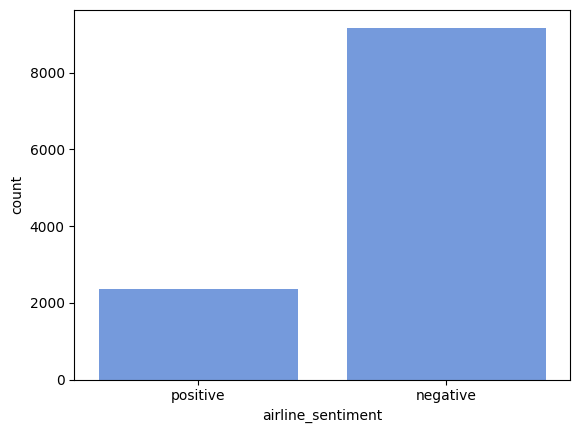

In [20]:
# Haz una trama de barra que muestre el recuento de sentimientos de tweets
sns.countplot(data=tweets,
              x='airline_sentiment', 
              color='cornflowerblue',
              order=['positive', 'negative']);

¡Parece que la mayoría de los tweets en este conjunto de datos están expresando un sentimiento negativo!

Echemos un vistazo a lo que se retuiteado más:

In [21]:
# Obtenga el recuento de retweet medio para cada sentimiento
tweets.groupby('airline_sentiment')['retweet_count'].mean()

airline_sentiment
negative    0.093375
positive    0.069403
Name: retweet_count, dtype: float64

¡Los tweets negativos se retuiteados claramente con más frecuencia que los positivos!

Veamos qué aerolínea recibe la mayoría de los tweets negativos:

In [22]:
# Obtenga la proporción de tweets negativos por aerolínea
proportions = tweets.groupby(['airline', 'airline_sentiment']).size() / tweets.groupby('airline').size()
proportions.unstack().sort_values('negative', ascending=False)

airline_sentiment,negative,positive
airline,,
US Airways,0.893760,0.106240
American,0.853659,0.146341
United,0.842560,0.157440
Southwest,0.675399,0.324601
Delta,0.637091,0.362909
Virgin America,0.543544,0.456456


¡Parece que las personas están más disacificadas con US Airways, seguidas de American Airline, y tienen más de 85 \% de tweets negativos!

Se podrían hacer muchos descubrimientos interesantes si desea explorar más sobre los datos.Ahora volvamos a nuestra tarea de análisis de sentimientos.Antes de eso, necesitamos preprocesar los datos de texto para que estén en un formato estándar.

<a id = 'section2'> </a>
# Preprocesamiento

Pasamos gran parte de la Parte 1 aprendiendo a preprocesar datos.¡Aplicemos lo que aprendimos!Mirando algunos de los tweets anteriores, podemos ver que si bien están en muy buena forma, podemos hacer un procesamiento adicional en ellos.

En nuestra tubería, omitiremos el proceso de tokenización ya que lo realizaremos en un paso posterior.

## 🥊 Desafío 1: Aplicar una tubería de limpieza de texto

Escriba una función llamada `Preprocess` que realice los siguientes pasos en una entrada de texto:

* Paso 1: minúscula la entrada de texto.
* Paso 2: Reemplace los siguientes patrones con marcadores de posición:
* URLS & RARR;`Url`
* Dígitos y rarr;`Dígito`
* Hashtags & rarr;`Hashtag`
* Tweet manejas y rarr;`Usuario`
* Paso 3: Elimine un espacio en blanco adicional.

Aquí hay algunos sugerencias para guiarlo a través de este desafío:

* Para el Paso 1, recuerde de la Parte 1 que un método de cadena llamado [`.lower ()`] (https://docs.python.org/3.11/library/stdtypes.html#str.lower) puede ser USD para convertir el texto en minúsculas.
* Tenemos el Paso 2 integrado en una función llamada 'marcador de posición`.Ejecute la celda a continuación para importarlo a su cuaderno, y puede usarlo como cualquier otra función.
* Para el paso 3, hemos proporcionado el patrón Regex para identificar caracteres en blanco, así como el reemplazo correcto para el espacio en blanco de extracto.

Ejecute su función 'Preprocess` en `Ejemplo_tweet` (tres celdas a continuación) para verificar si funciona.Si lo hace, aplíquelo a toda la columna `Text` en Tweets DataFrame.

In [44]:
import re

def placeholder(text):
    # Reemplaza URLs por el token <URL>
    text = re.sub(r'https?://\S+', '<URL>', text)
    # Reemplaza menciones (ej. @usuario) por <MENTION>
    text = re.sub(r'@\w+', '<MENTION>', text)
    # Reemplaza hashtags por <HASHTAG>
    text = re.sub(r'#\w+', '<HASHTAG>', text)
    return text


In [48]:
blankspace_pattern = r'\s+'
blankspace_repl = ' '

def preprocess(text):
    '''Create a preprocess pipeline that cleans the tweet data.'''

    # Step 1: Lowercase
    text = text.lower()

    # Step 2: Replace patterns with placeholders
    text = placeholder(text)

    # Step 3: Remove extra whitespace characters
    text = re.sub(blankspace_pattern, blankspace_repl, text)
    text = text.strip()
    
    return text

In [49]:
example_tweet = 'lol @justinbeiber and @BillGates are like soo 2000 #yesterday #amiright saw it on https://twitter.com #yolo'

# Imprime el tweet de ejemplo
print(example_tweet)
print(f"{'='*50}")

# Imprima el tweet preprocesado
print(preprocess(example_tweet))

lol @justinbeiber and @BillGates are like soo 2000 #yesterday #amiright saw it on https://twitter.com #yolo
lol <MENTION> and <MENTION> are like soo 2000 <HASHTAG> <HASHTAG> saw it on <URL> <HASHTAG>


In [50]:
# Aplicar la función a la columna de texto y asignar los tweets preprocesados ​​a una nueva columna
tweets['text_processed'] = tweets['text'].apply(lambda x: preprocess(x))
tweets['text_processed'].head()

0    <MENTION> plus you've added commercials to the...
1    <MENTION> it's really aggressive to blast obno...
2    <MENTION> and it's a really big bad thing abou...
3    <MENTION> seriously would pay $30 a flight for...
4    <MENTION> yes, nearly every time i fly vx this...
Name: text_processed, dtype: object

¡Felicidades!El preprocesamiento se realiza.¡Vamos a sumergirnos en la bolsa de palabras!

<a id = 'section3'> </a>
# La representación de la bolsa de palabras

La idea de la bolsa de palabras (arco), como su nombre indica, es bastante intuitiva: tomamos un documento y lo lanzamos en una bolsa.La acción de "arrojar" el documento en una bolsa ignora la posición relativa entre las palabras, entonces lo que está "en la bolsa" es esencialmente "un conjunto de palabras sin clasificar" [(Jurafsky y Martin, 2024)] (https://web.stanford.edu/~jurafsky/slp3/ed3book.pdf).A cambio, tenemos una lista de palabras únicas y la frecuencia de cada una de ellas.

Por ejemplo, como se muestra en la siguiente ilustración, la palabra "café" aparece dos veces.

<img src = '../../images/bow-illustration-1.png' alt = "bow-part2" width = "600">

Con una representación de la bolsa de palabras, hacemos un uso intensivo de la frecuencia de las palabras, pero no demasiado del orden de las palabras.

En el contexto del análisis de sentimientos, el sentimiento de un tweet se transmite más fuertemente por palabras específicas.Por ejemplo, si un tweet contiene la palabra "feliz", es probable que transmita un sentimiento positivo, pero no siempre (por ejemplo, "no feliz" denota el sentimiento opuesto).Cuando estas palabras surjan con más frecuencia, probablemente transmitirán más fuertemente el sentimiento.

## Matriz de término de documento

Ahora implementemos la idea de la bolsa de palabras.Antes de sumergirnos más profundamente, retrocedamos por un momento.En la práctica, el análisis de texto a menudo implica manejar muchos documentos;De ahora en adelante, usamos el término documento ** ** para representar un texto en el que realizamos el análisis.Podría ser una frase, una oración, un tweet o cualquier otro texto, siempre que pueda representarse por una cadena, la longitud no importa realmente.

Imagine que tenemos cuatro documentos (es decir, las cuatro frases que se muestran arriba), y los lanzamos todos en la bolsa.En lugar de una lista de frecuencia de palabras, esperaríamos una matriz de documento (DTM) a cambio.En un DTM, la lista de palabras es el vocabulario ** ** (v) que contiene todas las palabras únicas que ocurren en los documentos.Para cada documento ** ** (d), contamos el número de ocurrencias de cada palabra en el vocabulario, y luego conectamos el número a la matriz.En otras palabras, el DTM que construiremos es una matriz $ d \ Times v $, donde cada fila corresponde a un documento, y cada columna corresponde a un token (o "término").

Los tokens únicos en este conjunto de documentos, organizados en orden alfabético, forman las columnas.Para cada documento, marcamos la ocurrencia de cada palabra presente en el documento.La representación numérica para cada documento es una fila en la matriz.Por ejemplo, el primer documento, "The Coffee Roaster", tiene la representación numérica $ [0, 1, 0, 0, 0, 1, 1, 0] $.

Tenga en cuenta que la columna de índice de izquierda ahora muestra estos documentos como texto, pero generalmente solo asignaríamos un índice a cada uno de ellos.

$$
\begin{array}{c|cccccccccccc}
 & \text{americano} & \text{coffee} & \text{iced} & \text{light} & \text{roast} & \text{roaster} & \text{the} & \text{time} \\\hline
\text{the coffee roaster} &0 &1	&0	&0	&0	&1	&1	&0 \\ 
\text{light roast} &0 &0	&0	&1	&1	&0	&0	&0 \\
\text{iced americano} &1 &0	&1	&0	&0	&0	&0	&0 \\
\text{coffee time} &0 &1	&0	&0	&0	&0	&0	&1 \\
\end{array}
$$

Para crear un DTM, utilizaremos `CountVectorizer` del paquete` sklearn`.

In [34]:
from sklearn.feature_extraction.text import CountVectorizer

La siguiente ilustración representa el flujo de trabajo de tres pasos de crear un DTM con `CountVectorizr`.

<img src = '../../images/CountVectorizer1.png' alt = "countvectorizer" width = "500">

Vamos a atravesar estos pasos con el ejemplo de juguete que se muestra arriba.

### Un ejemplo de juguete

In [51]:
# Un ejemplo de juguete que contiene cuatro documentos
test = ['the coffee roaster',
        'light roast',
        'iced americano',
        'coffee time']

El primer paso es inicializar un objeto 'CountVectorizer`.Dentro de los paratheses redondos, podemos especificar la configuración de los parámetros si lo desea.Echemos un vistazo a la [documentación] (https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.countvectorizer.html) y vea qué opciones están disponibles.

Por ahora podemos dejarlo en blanco para usar la configuración predeterminada.

In [15]:
# Crear un objeto CountVectorizer
vectorizer = CountVectorizer()

El segundo paso es `Fit 'este objeto` CountVectorizer` a los datos, lo que significa crear un vocabulario de tokens desde el conjunto de documentos.En tercer lugar, `transformamos" nuestros datos de acuerdo con el objeto "ajustado" `CountVectorizer`, lo que significa tomar cada documento y contar las ocurrencias de tokens de acuerdo con el vocabulario establecido durante el paso de" ajuste ".

Puede sonar un poco complejo, pero los pasos 2 y 3 se pueden hacer en un swoop utilizando una función 'Fit_transform`.

In [16]:
# Fit y transformar para crear un DTM
test_count = vectorizer.fit_transform(test)

Se supone que la devolución de `Fit_Transform` es el DTM.

¡Echemos un vistazo!

In [17]:
test_count

<4x8 sparse matrix of type '<class 'numpy.int64'>'
	with 9 stored elements in Compressed Sparse Row format>

Aparentemente tenemos una "matriz escasa", una matriz que contiene muchos ceros.Esto tiene sentido.Para cada documento, hay palabras que no ocurren en absoluto, y estas se cuentan como cero en el DTM.Esta matriz dispersa se almacena en un formato de "fila dispersa comprimida", un formato de ahorro de memoria diseñado para manejar matrices dispersas.

Conviertala en una matriz densa, donde esos ceros probablemente estén representados, como en una matriz numpy.

In [18]:
# Convertir DTM a una matriz densa
test_count.todense()

matrix([[0, 1, 0, 0, 0, 1, 1, 0],
        [0, 0, 0, 1, 1, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0],
        [0, 1, 0, 0, 0, 0, 0, 1]])

¡Así que este es nuestro DTM!La matriz es la misma que se muestra arriba.Para que sea más amigable para los lectores, convímímoslo en un marco de datos.Los nombres de la columna deben ser tokens en el vocabulario, al que podemos acceder con la función 'get_feature_names_out`.

In [19]:
# Recuperar el vocabulario
vectorizer.get_feature_names_out()

array(['americano', 'coffee', 'iced', 'light', 'roast', 'roaster', 'the',
       'time'], dtype=object)

In [20]:
# Crear un marcador de datos DTM
test_dtm = pd.DataFrame(data=test_count.todense(),
                        columns=vectorizer.get_feature_names_out())

¡Aquí lo tienes!El DTM de nuestros datos de juguete es ahora un marcado de datos.El índice de `test_dtm` corresponde a la posición de cada documento en la lista de 'prueba'.

In [21]:
test_dtm

,americano,coffee,iced,light,roast,roaster,the,time
0,0,1,0,0,0,1,1,0
1,0,0,0,1,1,0,0,0
2,1,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,1


Esperemos que este ejemplo de juguete proporcione un recorrido claro de la creación de un DTM.

¡Ahora es el momento de nuestros datos de Tweets!

### DTM para tweets

Comenzaremos inicializando un objeto 'CountVectorizer`.En la siguiente celda, hemos incluido algunos parámetros que las personas a menudo ajustan.Estos parámetros se establecen actualmente en sus valores predeterminados.

Cuando construimos un DTM, el valor predeterminado es reducir el texto de entrada.Si no se proporciona nada para `stop_words`, el valor predeterminado es conservarlos.Los siguientes tres parámetros se utilizan para controlar el tamaño del vocabulario, al que volveremos en un minuto.

In [22]:
# Crear un objeto CountVectorizer
vectorizer = CountVectorizer(lowercase=True,
                             stop_words=None,
                             min_df=1,
                             max_df=1.0, 
                             max_features=None)

In [23]:
# Fit y transformar para crear DTM
counts = vectorizer.fit_transform(tweets['text_processed'])
counts

<11541x8751 sparse matrix of type '<class 'numpy.int64'>'
	with 191139 stored elements in Compressed Sparse Row format>

In [24]:
# No se ejecute si tiene memoria limitada, esto incluye Datahub y Binder
np.array(counts.todense())

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [25]:
# Extraer tokens
tokens = vectorizer.get_feature_names_out()

In [26]:
# Crear dtm
first_dtm = pd.DataFrame(data=counts.todense(),
                         index=tweets.index,
                         columns=tokens)

# Imprimir la forma de DTM
print(first_dtm.shape)

(11541, 8751)


Si dejamos el `CountVectorizer` a la configuración predeterminada, el tamaño del vocabulario de los datos de tweets es 8751.

In [27]:
first_dtm.head()

,_exact_,_wtvd,aa,aaaand,aadv,aadvantage,aal,aaron,ab,aback,...,zero,zig,zip,zippers,zone,zones,zoom,zukes,zurich,zz
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


La mayoría de los tokens tienen cero ocurrencias al menos en los primeros cinco tweets.

¡Echemos un vistazo más de cerca al DTM!

In [28]:
# Tokens más frecuentes
first_dtm.sum().sort_values(ascending=False).head(10)

user      12882
to         6987
digit      6927
the        5088
you        3635
for        3386
flight     3320
and        3276
on         3142
my         2751
dtype: int64

In [29]:
# Fichas menos frecuentes
first_dtm.sum().sort_values(ascending=True).head(10)

_exact_                     1
mightmismybrosgraduation    1
midterm                     1
midnite                     1
midland                     1
michelle                    1
michele                     1
michael                     1
mhtt                        1
mgmt                        1
dtype: int64

No es sorprendente ver que el "usuario" y el "dígito" se encuentren entre los tokens más frecuentes, ya que reemplazamos cada idiosincrásico con estos marcadores de posición.El resto de las fichas más frecuentes son en su mayoría palabras de parada.

Quizás un patrón más interesante es buscar qué token aparece más en cualquier tweet dado:

In [30]:
counts = pd.DataFrame()

# Recuperar el índice del tweet donde un token aparece con mayor frecuencia
counts['token'] = first_dtm.idxmax(axis=1)

# Recuperar el número de ocurrencia
counts['number'] = first_dtm.max(axis=1)

# Filtrar a los marcadores de posición
counts[(counts['token']!='digit')
       & (counts['token']!='hashtag')
       & (counts['token']!='user')].sort_values('number', ascending=False).head(10)

,token,number
3127,lt,6
918,worst,6
10572,to,5
8148,the,5
10742,to,5
152,to,5
5005,to,5
10923,the,5
7750,to,5
355,to,5


Parece que entre todos los tweets, como máximo, un token aparece seis veces, y es la palabra "it" o la palabra "peor".

Volvamos a nuestros Tweets DataFrame y ubicemos el tweet 918.

In [31]:
# Recuperar 918º Tweet: "peor"
tweets.iloc[918]['text']

"@united is the worst. Worst reservation policies. Worst costumer service. Worst worst worst. Congrats, @Delta you're not that bad!"

## Personalizar el `countvectorizer`

Hasta ahora, siempre hemos utilizado la configuración de parámetros predeterminada para crear nuestros DTMS, pero en muchos casos es posible que deseemos personalizar el objeto 'CountVectorizer`.El propósito de hacerlo es filtrar aún más las fichas innecesarias.En el ejemplo a continuación, modificamos los siguientes parámetros:

- `stop_words = 'inglés' ': ignorar palabras de parada en inglés
- `min_df = 2`: Ignorar palabras que no ocurren al menos dos veces
- `max_df = 0.95`: ignora las palabras si aparecen en más del 95 \% de los documentos

🔔 ** Pregunta **: ¡Hagamos un minuto para discutir si suena razonable establecer estos parámetros!¿Qué opinas?

A menudo, no estamos interesados ​​en palabras cuyas frecuencias son demasiado bajas o demasiado altas, por lo que usamos `min_df` y` max_df` para filtrarlas.Alternativamente, podemos definir nuestro tamaño de vocabulario como $ N $ configurando 'Max_Feature`.En otras palabras, le decimos a 'CountVectorizer' que solo considere los tokens más frecuentes de $ N $ al construir el DTM.

In [32]:
# Personalizar la configuración de parámetros
vectorizer = CountVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

In [33]:
# Fit, transformar y obtener fichas
counts = vectorizer.fit_transform(tweets['text_processed'])
tokens = vectorizer.get_feature_names_out()

# Create the second DTM
second_dtm = pd.DataFrame(data=counts.todense(),
                          index=tweets.index,
                          columns=tokens)

Nuestro segundo DTM tiene un vocabulario sustancialmente más pequeño en comparación con el primero.

In [34]:
print(first_dtm.shape)
print(second_dtm.shape)

(11541, 8751)
(11541, 4471)


In [35]:
second_dtm.head()

,aa,aadv,aadvantage,aal,abandoned,abc,ability,able,aboard,abq,...,yummy,yup,yvonne,yvr,yyj,yyz,zero,zone,zoom,zurich
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


La lista de tokens más frecuente ahora incluye palabras que tienen más sentido para nosotros, como "cancelado" y "servicio".

In [36]:
second_dtm.sum().sort_values(ascending=False).head(10)

digit        6927
flight       3320
hashtag      2633
cancelled     956
thanks        921
service       910
just          801
customer      726
time          695
help          687
dtype: int64

## 🥊 Desafío 2: Lemmatice la entrada de texto

Recuerde de la Parte 1 que introdujimos usando `Spacy` para realizar lemmatización, es decir, para" recuperar "la forma base de una palabra.Este proceso reducirá el tamaño del vocabulario manteniendo mínimo las variaciones de palabras: un vocabulario más pequeño puede ayudar a mejorar el rendimiento del modelo en la clasificación de sentimientos.

Ahora implementemos lemmatización en nuestros datos de tweets y usemos el texto lemmatizado para crear un tercer DTM.

Complete la función `lemmatize_text`.Requiere una entrada de texto y devuelve los lemas de todos los tokens.

Aquí hay algunos sugerencias para guiarlo a través de este desafío:

- Paso 1: Inicializar una lista para retener Lemmas
- Paso 2: aplique la tubería `NLP` al texto de entrada
- Paso 3: iterar sobre las fichas en el texto procesado y recuperar el lema del token
- Sugerencia: la lemmatización es una de las anotaciones lingüísticas que la tubería `NLP` hace automáticamente por nosotros.Podemos usar `token.lemma_` para acceder a la anotación.

In [37]:
# Import spacy
import spacy
nlp = spacy.load('en_core_web_sm')

In [ ]:
# Crear una función para limitar el texto
def lemmatize_text(text):
    '''Lemmatize the text input with spaCy annotations.'''

# Paso 1: Inicializar una lista vacía para mantener lemmas
    lemma = ...

# Paso 2: aplique la tubería NLP al texto de entrada
    doc = ...

# Paso 3: iterar sobre las fichas en el texto para obtener el lema de token
    for token in doc:
        lemma.append(...)

# Paso 4: une a Lemmas juntos en una sola cadena
    text_lemma = ' '.join(lemma)
    
    return text_lemma

¡Aplicemos la función al siguiente tweet de ejemplo primero!

In [39]:
# Aplicar la función a un tweet de ejemplo
print(tweets.iloc[33]["text_processed"])
print(f"{'='*50}")
print(lemmatize_text(tweets.iloc[33]['text_processed']))

USER wow this just blew my mind
USER wow this just blow my mind


Y luego limitemos los datos de los tweets y guardemos la salida en una nueva columna `text_lemmatized`.

In [40]:
# ¡Esto puede llevar un tiempo!
tweets['text_lemmatized'] = tweets['text_processed'].apply(lambda x: lemmatize_text(x))

Ahora con la columna `text_lemmatized`, creemos un tercer dtm.La configuración del parámetro es la misma que la segunda DTM.

In [41]:
# Crear el vectorizador (la misma configuración de parámetro que anteriormente)
vectorizer = CountVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

# Fit, transformar y obtener fichas
counts = vectorizer.fit_transform(tweets['text_lemmatized'])
tokens = vectorizer.get_feature_names_out()

# Crea el tercer dtm
third_dtm = pd.DataFrame(data=counts.todense(),
                         index=tweets.index,
                         columns=tokens)
third_dtm.head()

,aa,aadv,aadvantage,aal,abandon,abc,ability,able,aboard,abq,...,yummy,yup,yvonne,yvr,yyj,yyz,zero,zone,zoom,zurich
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [42]:
# Imprima las formas de tres DTMS
print(first_dtm.shape)
print(second_dtm.shape)
print(third_dtm.shape)

(11541, 8751)
(11541, 4471)
(11541, 3553)


Imprimamos los 10 tokens más frecuentes como de costumbre.Estos tokens ahora son lemas y sus recuentos también cambian después de la lemmatización.

In [43]:
# Obtenga las fichas más frecuentes en el tercer DTM
third_dtm.sum().sort_values(ascending=False).head(10)

digit       6927
flight      4043
hashtag     2633
thank       1455
hour        1134
cancel       948
delay        937
service      937
customer     902
time         856
dtype: int64

In [44]:
# En comparación con las tokens más frecuentes en el segundo DTM
second_dtm.sum().sort_values(ascending=False).head(10)

digit        6927
flight       3320
hashtag      2633
cancelled     956
thanks        921
service       910
just          801
customer      726
time          695
help          687
dtype: int64

<a id = 'section4'> </a>

# Frecuencia de documento de la frecuencia de término

Hasta ahora, confiamos en la frecuencia de las palabras para darnos información sobre un documento.Esto supone que si una palabra aparece más a menudo en un documento, es más informativo.Sin embargo, este no siempre es el caso.Por ejemplo, ya hemos eliminado las palabras de parada porque no son informativas, a pesar del hecho de que aparecen muchas veces en un documento.También sabemos que la palabra "vuelo" es una de las palabras más frecuentes, pero no es tan informativo, porque aparece en muchos documentos.¡Dado que estamos mirando los tweets de las aerolíneas, no deberíamos sorprendernos al ver la palabra "vuelo"!

Para remediar esto, utilizamos un esquema de ponderación llamado ** TF-IDF (frecuencia de documento de la frecuencia de término) **.La gran idea detrás de TF-IDF es ponderar una palabra no solo por su frecuencia dentro de un documento, sino también por su frecuencia en un documento en relación con los documentos restantes.Entonces, cuando construimos el DTM, asignaremos cada término una puntuación ** TF-IDF **.Específicamente, el término $ t $ en documento $ d $ se le asigna una puntuación TF-IDF de la siguiente manera:

<img src = '../../images/tf-idf_finalized.png' alt = "tf-idf" width = "1200">

En esencia, la puntuación TF-IDF de una palabra en un documento es el producto de dos componentes: ** Frecuencia de término (TF) ** y ** frecuencia de documento inversa (IDF) **.La FDI actúa como un factor de escala.Si se produce una palabra en todos los documentos, entonces IDF es igual a 1. No se producirá escala.Pero las FDI suelen ser mayor que 1, que es el peso que asignamos a la palabra para hacer que la puntuación TF-IDF sea más alta, para resaltar que la palabra es informativa.En la práctica, agregamos 1 tanto al denominador como al numerador ("add-1 suave") para evitar cualquier problema con cero ocurrencias.

También podemos crear un DTM TF-IDF usando `sklearn`.Usaremos un `tfidfvectorizer` esta vez:

In [45]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [46]:
# Crear un vectorizador TFIDF
vectorizer = TfidfVectorizer(lowercase=True,
                             stop_words='english',
                             min_df=2,
                             max_df=0.95,
                             max_features=None)

In [47]:
# Fit and Transform
tf_dtm = vectorizer.fit_transform(tweets['text_lemmatized'])
tf_dtm

<11541x3553 sparse matrix of type '<class 'numpy.float64'>'
	with 88287 stored elements in Compressed Sparse Row format>

In [48]:
# Crear un DataFrame de datos TF-IDF
tfidf = pd.DataFrame(tf_dtm.todense(),
                     columns=vectorizer.get_feature_names_out(),
                     index=tweets.index)
tfidf.head()

,aa,aadv,aadvantage,aal,abandon,abc,ability,able,aboard,abq,...,yummy,yup,yvonne,yvr,yyj,yyz,zero,zone,zoom,zurich
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Es posible que haya notado que el tamaño del vocabulario es el mismo que vimos en Challenge 2. Esto se debe a que utilizamos la misma configuración de parámetros al crear el vectorizador.Pero los valores en la matriz son diferentes: son puntajes TF-IDF en lugar de recuentos sin procesar.

## Interpretar los valores de TF-IDF

Echemos un vistazo al documento donde un término tiene los valores TF-IDF más altos.Usaremos el método `.idxmax ()` para encontrar el índice.

In [49]:
# Recuperar el índice del documento
tfidf.idxmax()

aa            10077
aadv           9285
aadvantage     9974
aal           10630
abandon        7859
              ...  
yyz            1350
zero           2705
zone           3177
zoom           3920
zurich        10622
Length: 3553, dtype: int64

Por ejemplo, el término "peor" ocurre más distintivamente en el tweet 918.

In [35]:
tfidf.idxmax()['worst']

NameError: name 'tfidf' is not defined

¡Recuerde que este es el tweet donde la palabra "peor" aparece seis veces!

In [51]:
tweets['text_processed'].iloc[918]

"USER is the worst. worst reservation policies. worst costumer service. worst worst worst. congrats, USER you're not that bad!"

¿Qué tal "cancelar"?Echemos un vistazo a otro ejemplo.

In [52]:
tfidf.idxmax()['cancel']

5945

In [53]:
tweets['text_processed'].iloc[5945]

'USER cancelled flighted 😢'

## 🥊 Desafío 3: Palabras con puntajes más medios de TF-IDF

Hemos obtenido valores de TF-IDF para cada término en cada documento.Pero, ¿qué nos dicen estos valores sobre los sentimientos de los tweets?¿Hay alguna palabra que sean particularmente informativas para los tweets positivos/negativos?

Para explorar esto, recopilemos los índices de todos los tweets positivos/negativos y calculemos las puntuaciones medias de palabras TF-IDF aparecen en cada categoría.

Hemos proporcionado el siguiente código de inicio para guiarlo:
- Subcontratando el `Tweets` DataFrame de acuerdo con la etiqueta` Airline_sentiment` y recupere el índice de cada subconjunto (`.index`).Asigne el índice a `positivo_index` o` negativo_index`.
- Para cada subconjunto:
- Recuperar la representación TD-IDF
- Tome los valores medios de TF-IDF a través del subconjunto usando `.ean ()`
- Ordene los valores medios en el orden descendente usando `.sort_values ​​()`
- Obtenga los 10 términos principales usando `.head ()`

A continuación, ejecute `pos.plot` y` neg.plot` para trazar las palabras con los puntajes TF-IDF más altos para cada subconjunto.

In [ ]:
# Completa las máscaras booleanas
positive_index = tweets[...].index
negative_index = tweets[...].index

In [ ]:
# Completa las siguientes dos líneas
pos = tfidf.loc[...].mean().sort_values(...).head(...)
neg = tfidf.loc[...].mean().sort_values(...).head(...)

In [ ]:
pos.plot(kind='barh', 
         xlim=(0, 0.18),
         color='cornflowerblue',
         title='Top 10 terms with the highest mean tf-idf values for positive tweets');

In [ ]:
neg.plot(kind='barh', 
         xlim=(0, 0.18),
         color='darksalmon',
         title='Top 10 terms with the highest mean tf-idf values for negative tweets');

🔔 ** Pregunta **: ¿Cómo interpretarías estos resultados?¡Comparte tus pensamientos en el chat!

<a id = 'section5'> </a>

## 🎬 ** Demo **: Clasificación de sentimientos utilizando la representación TF-IDF

Ahora que tenemos una representación de TF-IDF del texto, ¡estamos listos para hacer un análisis de sentimientos!

En esta demostración, utilizaremos un modelo de regresión logística para realizar la tarea de clasificación.Aquí avanzamos brevemente cómo la regresión logística funciona como uno de los métodos de aprendizaje automático supervisado, pero no dude en explorar nuestro taller en [Python Machine Learning Fundaments] (https://github.com/dlab-berkeley/python-machine-Learning) si desea obtener más información sobre él.

La regresión logística es un modelo lineal, con el que usamos para predecir la etiqueta de un tweet, basado en un conjunto de características ($ x_1, x_2, x_3, ..., x_i $), como se muestra a continuación:

$$
L = \ beta_1 x_1 + \ beta_2 x_2 + \ cdots + \ beta_t x_t
$$

La lista de características que pasaremos al modelo es el vocabulario del DTM.También alimentamos el modelo con una parte de los datos, conocido como conjunto de capacitación, junto con otra especificación del modelo, para aprender el coeficiente ($ \ beta_1, \ beta_2, \ beta_3, ..., \ beta_i $) de cada característica.Los coeficientes nos dicen si una característica contribuye de manera positiva o negativa al valor predicho.El valor predicho corresponde a agregar todas las características (multiplicadas por sus coeficientes), y el valor predicho se pasa a una [función sigmoide] (https://en.wikipedia.org/wiki/sigmoid_function) para convertirse en el espacio de probabilidad, que nos dice si la etiqueta predicha es positiva (cuando $ P> 0.5 $) o negativo (cuándo $).

La porción restante de los datos, conocida como el conjunto de pruebas, se utiliza para probar si los coeficientes aprendidos podrían generalizarse a datos invisibles.

Ahora que ya tenemos el TF-IDF DataFrame, el conjunto de características está listo.¡Vamos a sumergirnos en la especificación del modelo!

In [55]:
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import train_test_split

Usaremos la función `Train_test_Split` de` sklearn` para separar nuestros datos en dos conjuntos:

In [56]:
# División de prueba de tren
X = tfidf
y = tweets['airline_sentiment']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15)

La función `Fit_Logistic_Regression` se escribe a continuación para optimizar el proceso de entrenamiento.

In [57]:
def fit_logistic_regression(X, y):
    '''Fits a logistic regression model to provided data.'''
    model = LogisticRegressionCV(Cs=10,
                                 penalty='l1',
                                 cv=5,
                                 solver='liblinear',
                                 class_weight='balanced',
                                 random_state=42,
                                 refit=True).fit(X, y)
    return model

Se ajustaremos al modelo y calcularemos la precisión de entrenamiento y prueba.

In [58]:
# Ajustar el modelo de regresión logística
model = fit_logistic_regression(X_train, y_train)

In [59]:
# Obtenga la precisión de entrenamiento y prueba
print(f"Training accuracy: {model.score(X_train, y_train)}")
print(f"Test accuracy: {model.score(X_test, y_test)}")

Training accuracy: 0.9455601998164951
Test accuracy: 0.894919168591224


El modelo logró ~ 94% de precisión en el conjunto de entrenamiento y ~ 89% en el conjunto de pruebas, ¡es bastante bueno!El modelo se generaliza razonablemente bien a los datos de prueba.

A continuación, echemos un vistazo a los coeficientes ajustados para ver si lo que vemos tiene sentido.

Podemos acceder a ellos usando `coef_`, y podemos igualar cada coeficiente con los tokens desde el vectorizador:

In [60]:
# Obtener coefs de todas las características
coefs = model.coef_.ravel()

# Consigue todas las fichas
tokens = vectorizer.get_feature_names_out()

# Crear un Token-CoEF DataFrame
importance = pd.DataFrame()
importance['token'] = tokens
importance['coefs'] = coefs

In [61]:
# Obtenga las 10 tokens principales con los coef más bajos
neg_coef = importance.sort_values('coefs').head(10)
neg_coef

,token,coefs
2724,rude,-11.138668
2784,screw,-9.962456
2727,ruin,-9.849836
1505,hour,-9.282416
389,break,-7.949487
2280,pay,-7.823908
458,cancel,-7.534084
264,bad,-7.357206
1872,luggage,-7.093317
3034,strand,-7.046890


In [62]:
# Obtenga las 10 tokens principales con los coef más altos
pos_coef = importance.sort_values('coefs').tail(10)
pos_coef 

,token,coefs
3165,thankful,8.002975
1091,exceptional,8.136278
1563,impressed,8.501364
648,compliment,8.981360
1373,great,9.080558
3498,wonderful,9.401606
1089,excellent,10.147230
250,awesome,10.315909
1746,kudo,11.623828
3164,thank,16.027534


Entriquemos las 10 tokens principales con los coeficientes más altos/más bajos.

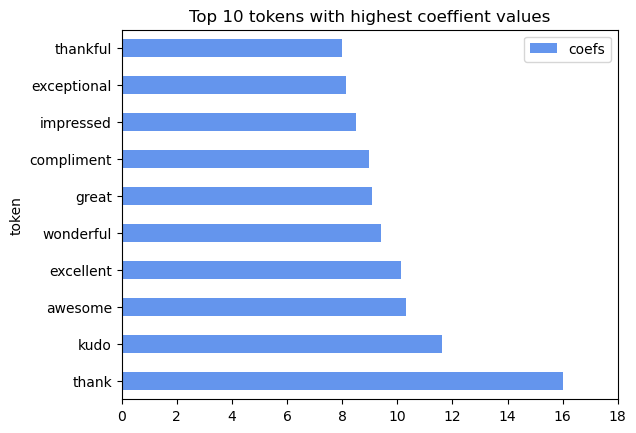

In [63]:
# Traza las 10 tokens principales que tienen los coef más altos
pos_coef.sort_values('coefs', ascending=False) \
        .plot(kind='barh', 
              xlim=(0, 18),
              x='token',
              color='cornflowerblue',
              title='Top 10 tokens with highest coeffient values');

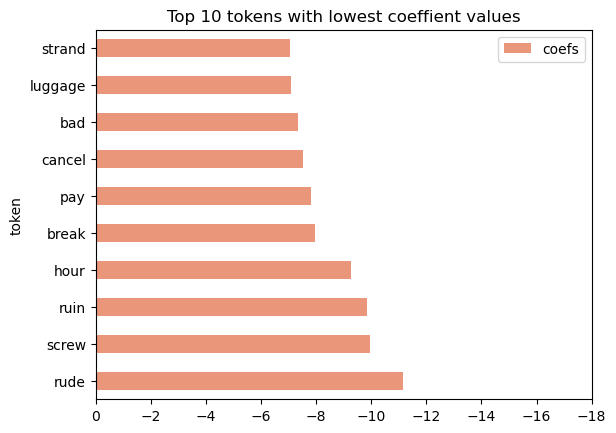

In [64]:
# Traza las 10 tokens principales que tienen los coef más bajos
neg_coef.plot(kind='barh', 
              xlim=(0, -18),
              x='token',
              color='darksalmon',
              title='Top 10 tokens with lowest coeffient values');

Palabras como "ruina", "grosero" y "hora" son fuertes indicadores de sentimiento negativo, mientras que "gracias", "impresionante" y "maravilloso" están asociados con un sentimiento positivo.

Envolveremos la Parte 2 con estas tramas.Estos términos de coeficientes y las palabras con los valores más altos de TF-IDF proporcionan diferentes perspectivas sobre el sentimiento de los tweets.Si lo desea, tómese un tiempo para comparar los dos conjuntos de parcelas y ver cuál proporciona una mejor cuenta de los sentimientos transmitidos en los tweets.

<div class = "alerta de alerta-exuces">

## ❗ Puntos clave

* Una representación de la bolsa de palabras es un método simple para transformar nuestros datos de texto en números.Se centra en la frecuencia de las palabras pero no en el orden de las palabras.
* Una representación TF-IDF está un paso más allá;También considera si una determinada palabra aparece de manera distintiva en un documento u ocurre uniformalmente en todos los documentos.
* Con una representación numérica, podemos realizar una gama de tarea de clasificación de texto, como el análisis de sentimientos.

</div>